# 00 · Your first EEG in MNE

**ROBT613 · Brain–Computer Interfaces** | 45–60 min

## Goal
Inspect sampling, voltage units, channel names and event markers; understand the Raw → Epochs → Evoked workflow before starting the P300 track.

**Data:** No external recording

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

An EEG channel measures a voltage difference, not an absolute brain potential. Synchronized postsynaptic currents from many similarly oriented neurons contribute to scalp EEG; skull and tissue spread their fields. A channel is therefore not a direct readout of one cortical source.

For samples $x_c[n]$ from channel $c$, time is $t_n=n/f_s$. Sampling at $f_s$ Hz only represents frequencies below $f_s/2$ without aliasing, assuming appropriate analog anti-alias filtering. MNE stores EEG in **volts**: $1\,\mu V=10^{-6}\,V$.

`Raw` holds continuous channels × time; `Epochs` holds trials × channels × time; `Evoked` is a trial average. `Info` carries units, sampling frequency, channel types and sensor geometry. Event sample indices are integer positions, while annotations use seconds. Confusing these conventions shifts labels away from physiology.

The controlled waveform below is explicitly synthetic: it checks your environment and units, not BCI performance. Real recordings begin in notebook 01.

## Build an inspectable recording
Make a known 10 Hz oscillation plus noise so you can verify the time and frequency axes.

/tmp/ipykernel_416938/4232803724.py:6: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  raw.set_montage('standard_1020')


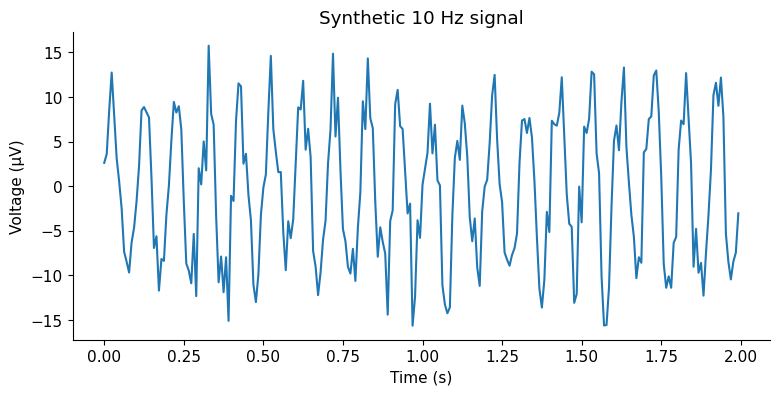

In [2]:
sfreq = 128.0
t = np.arange(1280) / sfreq
wave = 10e-6 * np.sin(2*np.pi*10*t)
raw = mne.io.RawArray(np.vstack([wave, wave + rng.normal(0, 3e-6, len(t))]),
                      mne.create_info(['C3','C4'], sfreq, 'eeg'))
raw.set_montage('standard_1020')
fig, ax = plt.subplots()
ax.plot(t[:256], raw.get_data()[1,:256]*1e6)
ax.set(xlabel='Time (s)', ylabel='Voltage (µV)', title='Synthetic 10 Hz signal')
plt.show()
assert raw.get_data().shape == (2,1280)

## From events to averages
The third event column is a condition code. Baseline subtraction removes each epoch’s pre-event mean; it is not a high-pass filter.

Raw: (2, 1280) Epochs: (4, 2, 104)


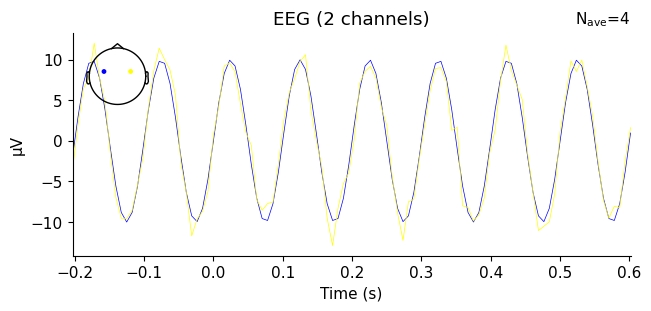

In [3]:
events = np.array([[256,0,1],[512,0,1],[768,0,1],[1024,0,1]])
epochs = mne.Epochs(raw, events, {'cue':1}, -0.2, 0.6, baseline=(-0.2,0), preload=True)
print('Raw:', raw.get_data().shape, 'Epochs:', epochs.get_data().shape)
epochs.average().plot(show=False)
plt.show()

## Exercises and checks
1. Change `sfreq` without changing the waveform generation and explain what must change together.
2. Deliberately enter 10 instead of `10e-6`. How does the amplitude check reveal the unit error?
3. Explain why a 10 Hz sine wave is not a simulation of the complete EEG generation process.

## Next steps and sources
[MNE data structures](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Continue to notebook 01.

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.